# 02 - Decision Tree (Flood Risk Classification)
**CSC61304 Group 6 - Flood Risk Nepal**

Loads the shared splits produced by `00_data_preprocessing_consolidated.ipynb`
and trains a Decision Tree classifier to predict `flood_risk_level_enc`
(Low / Moderate / High / Extreme) for a district in a given 10-day period,
from the CHIRPS rainfall features.

```bash
pip install pandas numpy matplotlib scikit-learn
```

## 1. Load the shared train/test splits

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

X_train = pd.read_csv("../dataset/processed/X_train.csv")
X_test = pd.read_csv("../dataset/processed/X_test.csv")
y_train = pd.read_csv("../dataset/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../dataset/processed/y_test.csv").squeeze()

# LabelEncoder in 00_ encodes flood_risk_level alphabetically:
# 0 = Extreme, 1 = High, 2 = Low, 3 = Moderate
class_names = ["Extreme", "High", "Low", "Moderate"]

print(X_train.shape, X_test.shape)
print(X_train.head())

(100962, 14) (25241, 14)
        rfh       r1h       r3h   rfh_avg   r1h_avg   r3h_avg       rfq  \
0  0.647664  0.603622  1.857398  0.605491  1.146329  1.933764  0.172816   
1  0.199676  0.033810 -0.008820  0.425987  0.135494 -0.312641 -0.278816   
2 -0.263880 -0.474888 -0.815483 -0.689811 -0.749124 -0.932043  2.505162   
3 -0.724878 -0.810668  0.144854 -0.820203 -0.848644 -0.420069 -0.239361   
4 -0.683753 -0.814146 -0.206547 -0.811158 -0.875533 -0.559694  0.194430   

        r1q       r3q  n_pixels      year     month  decade_num  \
0 -0.596898 -0.010529 -0.695040  1.577366  0.733915    0.000747   
1 -0.236653  1.295889  0.224029 -0.172442 -0.135432   -1.223811   
2  2.980859  2.120754  0.883873  1.196973 -1.294561   -1.223811   
3 -0.469495  2.849112 -0.341552 -1.541856  1.313479    1.225306   
4  0.159008  2.203857  0.412556  1.349130  1.603261   -1.223811   

   district_zone_enc  
0           1.460273  
1          -0.957813  
2           1.460273  
3          -0.957813  
4     

## 2. Train the model

In [5]:
dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

## 3. Evaluate - Accuracy, Precision, Recall, F1, Confusion Matrix

Accuracy : 1.0000
Precision: 1.0000  (weighted)
Recall   : 1.0000  (weighted)
F1-score : 1.0000  (weighted)

Full classification report:

              precision    recall  f1-score   support

     Extreme       1.00      1.00      1.00       757
        High       1.00      1.00      1.00      1767
         Low       1.00      1.00      1.00     18931
    Moderate       1.00      1.00      1.00      3786

    accuracy                           1.00     25241
   macro avg       1.00      1.00      1.00     25241
weighted avg       1.00      1.00      1.00     25241



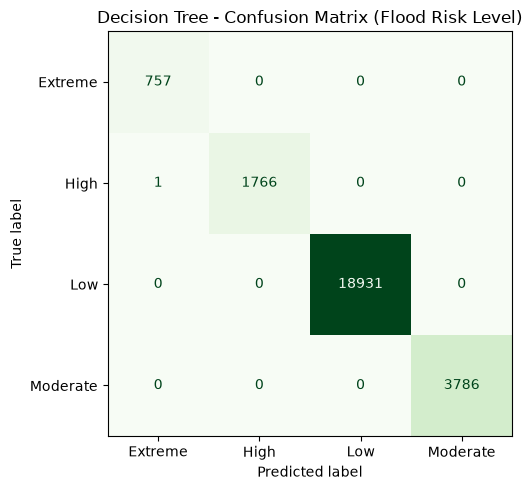

In [3]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (weighted)")
print(f"Recall   : {recall:.4f}  (weighted)")
print(f"F1-score : {f1:.4f}  (weighted)")

print("\nFull classification report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title("Decision Tree - Confusion Matrix (Flood Risk Level)")
plt.tight_layout()
plt.show()

## 4. Visualise the tree and feature importance

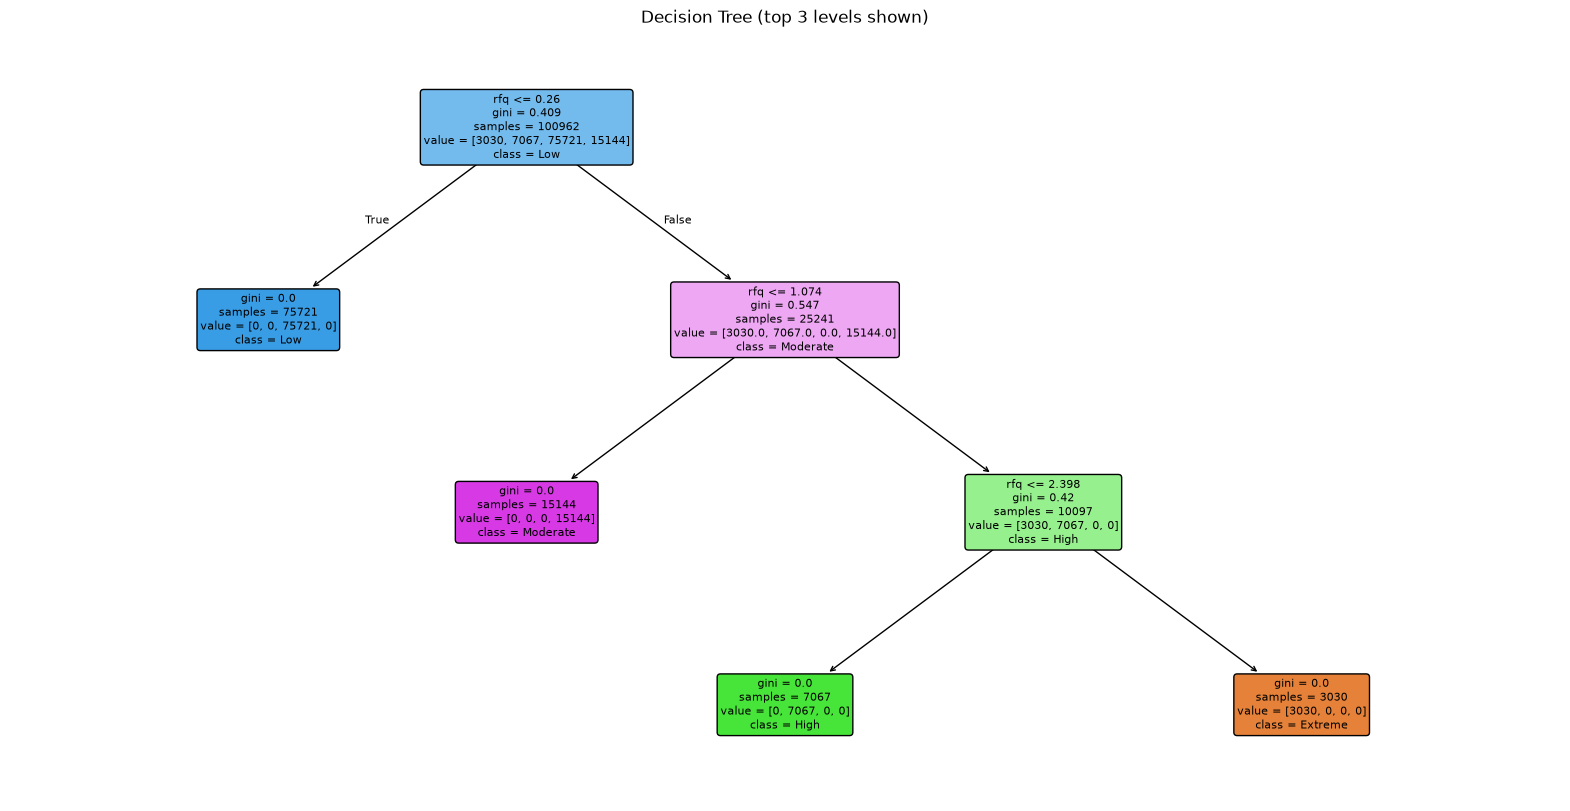

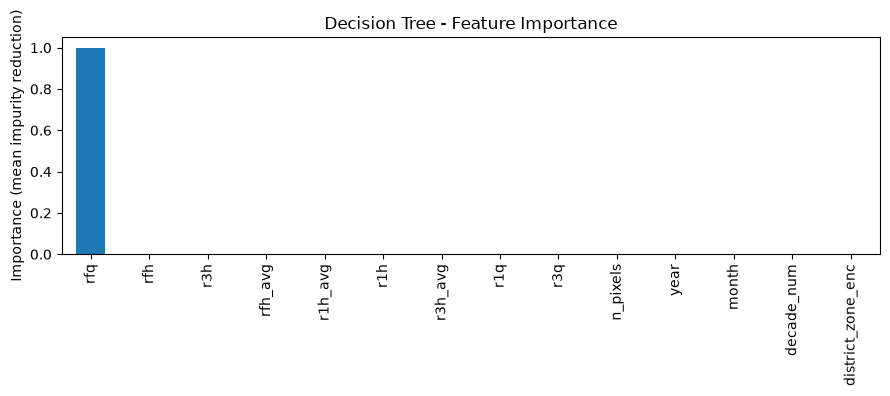

rfq                  1.0
rfh                  0.0
r3h                  0.0
rfh_avg              0.0
r1h_avg              0.0
r1h                  0.0
r3h_avg              0.0
r1q                  0.0
r3q                  0.0
n_pixels             0.0
year                 0.0
month                0.0
decade_num           0.0
district_zone_enc    0.0
dtype: float64


In [4]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X_train.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3  # only show the top 3 levels for readability; full tree is deeper
)
plt.title("Decision Tree (top 3 levels shown)")
plt.show()

importances = pd.Series(dt.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(9, 4))
plt.title("Decision Tree - Feature Importance")
plt.ylabel("Importance (mean impurity reduction)")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))